This notebook aims to take the address of each communard's home and from it assign two categories: arrondissement and coordinates. The former will allow a neighborhood check, the latter a more direct distance check.

Dataset of Paris quartiers is found here: https://opendata.paris.fr/explore/dataset/quartier_paris/export/?disjunctive.c_ar.

The spelling is corrected in the quartiers dataset to match that in the communard set.

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('data/communards_clean.csv')
quartiers = pd.read_csv('data/quartier_paris.csv', sep=';', engine='python', encoding='utf-8', on_bad_lines='skip')
quartiers.head()

,N_SQ_QU,C_QU,C_QUINSEE,L_QU,C_AR,N_SQ_AR,PERIMETRE,SURFACE,Geometry X Y,Geometry,st_area(shape),st_perimeter(shape)
0,750000022,22,7510602,Odéon,6,750000006,3516.314464,7.161484e+05,"48.847800629292664, 2.3363388275876775","{""coordinates"": [[[2.3369886672065507, 48.8529...",7.161484e+05,3516.110384
1,750000043,43,7511103,Roquette,11,750000011,4973.010557,1.172087e+06,"48.85706404083103, 2.380364061726767","{""coordinates"": [[[2.3797208188869265, 48.8534...",1.172087e+06,4972.768946
2,750000035,35,7510903,Faubourg-Montmartre,9,750000009,2786.541926,4.173351e+05,"48.873934691758095, 2.343252579473346","{""coordinates"": [[[2.340255299125085, 48.87660...",4.173351e+05,2786.448978
3,750000006,6,7510202,Vivienne,2,750000002,2058.472959,2.435508e+05,"48.86910019977125, 2.3394607437483312","{""coordinates"": [[[2.341232901135718, 48.86580...",2.435508e+05,2058.393947
4,750000011,11,7510303,Archives,3,750000003,2534.100042,3.677284e+05,"48.859192412713874, 2.3632050573309638","{""coordinates"": [[[2.3684797205288945, 48.8558...",3.677284e+05,2533.985804


In [3]:
from rapidfuzz import process, fuzz

quartier_choices = quartiers['L_QU'].dropna().astype(str).str.strip().unique().tolist()

def match_arrondissement(q):
    if pd.isna(q):
        return pd.NA
    match = process.extractOne(
        str(q).strip(),
        quartier_choices,
        scorer=fuzz.WRatio
    )
    if match and match[1] >= 80:
        return quartiers.loc[quartiers['L_QU'].astype(str).str.strip().eq(match[0]), 'C_AR'].iloc[0]
    return pd.NA

df['arrondissement'] = df['add_quartier'].apply(match_arrondissement)

In [4]:
# Find quartiers that didn't get a match in the df dataset
unmatched_quartiers = quartiers[~quartiers['L_QU'].astype(str).str.strip().str.lower().isin(
    df['add_quartier'].astype(str).str.strip().str.lower()
)]

print("Quartiers with no matches in the communards dataset:")
print(unmatched_quartiers[['L_QU', 'C_AR']])

Quartiers with no matches in the communards dataset:
                         L_QU  C_AR
2         Faubourg-Montmartre     9
8              Enfants-Rouges     3
9               Saint-Fargeau    20
12                    Bel-Air    12
15       Saint-Thomas-d'Aquin     7
16             Champs-Elysées     8
17              Saint-Georges     9
18           Chaussée-d'Antin     9
20  Saint-Germain-l'Auxerrois     1
23             Bonne-Nouvelle     2
26            Arts-et-Métiers     3
27                La Chapelle    18
29                Saint-Merri     4
37         Parc-de-Montsouris    14
41     Saint-Germain-des-Prés     6
42        Hôpital-Saint-Louis    10
43            Ecole-Militaire     7
45            Petit-Montrouge    14
47             Saint-Ambroise    11
48             Maison-Blanche    13
55             Porte-Dauphine    16
57      Notre-Dame-des-Champs     6
58          Faubourg-du-Roule     8
59              Saint-Lambert    15
61          Grandes-Carrières    18
62         

In [5]:
df.head()

,Profile_URL,Raw_Bio_Text,Lieu de naissance,Date de naissance déclarée,Âge déclaré,Âge calculé au 31 mai 1871,État civil,Père,Mère,Adresse,...,national_guard_rank,national_guard_batallion,add_city,add_department,add_house_number,add_street_raw,add_street,add_quartier,age,arrondissement
0,https://communards-1871.fr/index.php?page=fich...,Aab – Pierre Eugène Informations personnelles ...,"Paris, Seine",25/04/1835,36 ans,36 ans,célibataire ou en concubinage - 1 enfant(s) dé...,Jacques,Chocat Joséphine,Paris - Seine 38 Rue Montreuil (de) (quartie...,...,Capitaine,206.0,Paris,Seine,38,Rue Montreuil (de),Rue deMontreuil,Sainte Marguerite,36.0,11
1,https://communards-1871.fr/index.php?page=fich...,Abadie – Antoine Informations personnelles Adr...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Paris - Seine,...,Adjudant major,57.0,NaN,NaN,NaN,Paris - Seine,Paris - Seine,NaN,NaN,<NA>
2,https://communards-1871.fr/index.php?page=fich...,Abadie – Antoine Informations personnelles Lie...,"Lembeye, Pyrénées (Basses)",11/10/1835,36 ans,36 ans,marié(e),Dominique,Lavallière Bernarde,Paris - Seine 17 Route Asnières (d’) (quarti...,...,Garde,132.0,Paris,Seine,17,Route Asnières (d’),Route d’Asnières,Plaine de Monceaux,36.0,17
3,https://communards-1871.fr/index.php?page=fich...,Abadie – Antoine Informations personnelles Lie...,"Tarbes, Pyrénées (Hautes)",03/10/1854,18 ans,17 ans,célibataire ou en concubinage,Pierre,Catherine,Paris - Seine 64 Avenue Clichy (de) (quartie...,...,Garde,207.0,Paris,Seine,64,Avenue Clichy (de),Avenue deClichy,Epinettes,17.0,17
4,https://communards-1871.fr/index.php?page=fich...,Abadie – Ismaël Isaac Informations personnelle...,"Vierzon, Cher",20/06/1820,NaN,51 ans,NaN,NaN,NaN,Paris - Seine 17 Rue Moreau (quartier Quinze...,...,NaN,NaN,Paris,Seine,17,Rue Moreau,Rue Moreau,Quinze Vingts,51.0,12


In [7]:
import os
import pandas as pd
import requests
import numpy as np
import re
from tqdm import tqdm

CHECKPOINT_PATH = 'data/geocoded_1871_addresses_checkpoint.csv'
FINAL_OUTPUT_PATH = 'data/geocoded_1871_addresses.csv'
SAVE_EVERY = 50


def geocode_ban(row):
    """Queries the French Base Adresse Nationale API with aggressive string cleaning."""
    number = str(row['add_house_number']) if pd.notna(row['add_house_number']) else ""
    street = str(row['add_street']) if pd.notna(row['add_street']) else ""

    if number.strip() in ['-', 'nan', 'Missing value', 'None']:
        number = ""
    if street.strip() in ['-', 'nan', 'Missing value', 'None']:
        street = ""

    if not street:
        return pd.Series([np.nan, np.nan, 0.0, 'missing_street'])

    raw_query = f"{number} {street}, Paris, France"
    clean_query = re.sub(r'\s+', ' ', raw_query).strip()
    clean_query = re.sub(r'^[^a-zA-Z0-9]+', '', clean_query)

    url = 'https://api-adresse.data.gouv.fr/search/'
    params = {
        'q': clean_query,
        'limit': 1
    }

    try:
        response = requests.get(url, params=params)
        response.raise_for_status()
        data = response.json()

        if data['features']:
            best_match = data['features'][0]
            lon, lat = best_match['geometry']['coordinates']
            score = best_match['properties']['score']
            result_type = best_match['properties']['type']
            return pd.Series([lat, lon, score, result_type])
        return pd.Series([np.nan, np.nan, 0.0, 'not_found'])

    except Exception as e:
        print(f"Error geocoding '{clean_query}': {e}")
        return pd.Series([np.nan, np.nan, 0.0, 'api_error'])


# Keep the original address table and merge checkpointed geocode columns back into it.
source_df = df.copy().reset_index(drop=True)
source_df['_checkpoint_id'] = source_df.index

if os.path.exists(CHECKPOINT_PATH):
    print(f"Loading checkpoint from {CHECKPOINT_PATH}")
    checkpoint_df = pd.read_csv(CHECKPOINT_PATH)
    if '_checkpoint_id' in checkpoint_df.columns:
        checkpoint_df = checkpoint_df.set_index('_checkpoint_id')
        source_df = source_df.set_index('_checkpoint_id')
        for column in ['latitude', 'longitude', 'confidence_score', 'match_type']:
            if column in checkpoint_df.columns:
                source_df[column] = checkpoint_df[column]
        df = source_df.reset_index()
    else:
        df = checkpoint_df
else:
    df = source_df.copy()

for column in ['latitude', 'longitude', 'confidence_score']:
    if column not in df.columns:
        df[column] = np.nan
    df[column] = pd.to_numeric(df[column], errors='coerce')

if 'match_type' not in df.columns:
    df['match_type'] = pd.Series([pd.NA] * len(df), dtype='string')
else:
    df['match_type'] = df['match_type'].astype('string')

pending_rows = df.index[df['latitude'].isna() | df['longitude'].isna() | df['match_type'].isna()]
print(f"Starting geocoding process for {len(pending_rows)} remaining rows...")

for position, row_index in enumerate(tqdm(pending_rows, total=len(pending_rows)), start=1):
    latitude, longitude, confidence_score, match_type = geocode_ban(df.loc[row_index])
    df.loc[row_index, ['latitude', 'longitude', 'confidence_score', 'match_type']] = [
        latitude,
        longitude,
        confidence_score,
        match_type,
    ]

    if position % SAVE_EVERY == 0 or position == len(pending_rows):
        df.to_csv(CHECKPOINT_PATH, index=False)
        print(f"Saved checkpoint after {position}/{len(pending_rows)} rows to {CHECKPOINT_PATH}")

out_df = df.drop(columns=['_checkpoint_id'], errors='ignore')
out_df.to_csv(FINAL_OUTPUT_PATH, index=False)
print(f"Geocoding complete. Final output saved to {FINAL_OUTPUT_PATH}")

Loading checkpoint from data/geocoded_1871_addresses_checkpoint.csv


/var/folders/zp/r_synnss3dnc2lgwfbyr07h80000gn/T/ipykernel_4130/2326141201.py:60: DtypeWarning: Columns (0: match_type) have mixed types. Specify dtype option on import or set low_memory=False.
  checkpoint_df = pd.read_csv(CHECKPOINT_PATH)


Starting geocoding process for 21978 remaining rows...


  0%|          | 51/21978 [00:08<2:26:39,  2.49it/s]

Saved checkpoint after 50/21978 rows to data/geocoded_1871_addresses_checkpoint.csv


...

100%|█████████▉| 21950/21978 [1:36:24<00:11,  2.52it/s]

Saved checkpoint after 21950/21978 rows to data/geocoded_1871_addresses_checkpoint.csv


100%|██████████| 21978/21978 [1:36:31<00:00,  3.79it/s]

Saved checkpoint after 21978/21978 rows to data/geocoded_1871_addresses_checkpoint.csv


Geocoding complete. Final output saved to data/geocoded_1871_addresses.csv


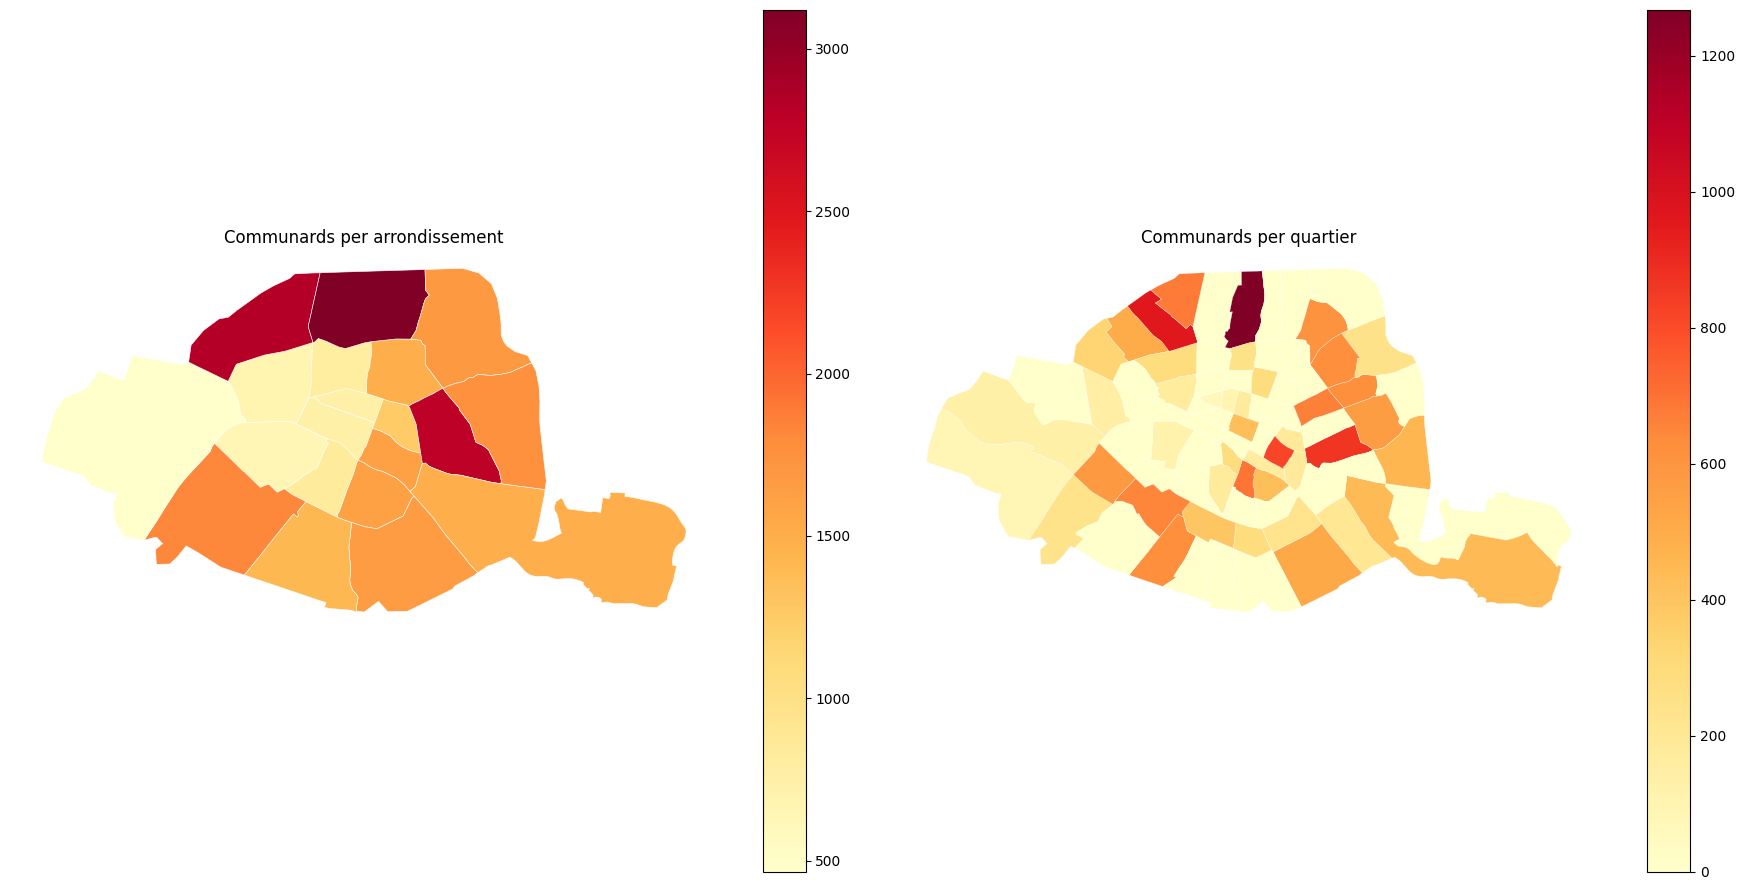

In [ ]:
import json

import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import shape

# Build geometries from the quartier dataset already loaded above.
quartier_geometries = quartiers.copy()
quartier_geometries["geometry"] = quartier_geometries["Geometry"].apply(
    lambda value: shape(json.loads(value)) if pd.notna(value) else None
)
quartier_geometries = gpd.GeoDataFrame(
    quartier_geometries,
    geometry="geometry",
    crs="EPSG:4326",
)

# Counts per arrondissement and per quartier.
arrondissement_counts = (
    df.dropna(subset=["arrondissement"])
    .groupby("arrondissement")
    .size()
    .reset_index(name="communards")
)
quartier_counts = (
    df.dropna(subset=["add_quartier"])
    .assign(add_quartier=lambda frame: frame["add_quartier"].astype(str).str.strip())
    .groupby("add_quartier")
    .size()
    .reset_index(name="communards")
)

# Prepare arrondissement polygons by dissolving the quartier geometries.
arrondissement_map = (
    quartier_geometries[["C_AR", "geometry"]]
    .dissolve(by="C_AR", as_index=False)
    .merge(arrondissement_counts, left_on="C_AR", right_on="arrondissement", how="left")
    .fillna({"communards": 0})
)

# Prepare quartier polygons and merge counts.
quartier_map_gdf = (
    quartier_geometries[["L_QU", "geometry"]]
    .merge(quartier_counts, left_on="L_QU", right_on="add_quartier", how="left")
    .fillna({"communards": 0})
)

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

arrondissement_map.plot(
    column="communards",
    ax=axes[0],
    cmap="YlOrRd",
    linewidth=0.4,
    edgecolor="white",
    legend=True,
    missing_kwds={"color": "#f0f0f0"},
)
axes[0].set_title("Communards per arrondissement")
axes[0].set_axis_off()

quartier_map_gdf.plot(
    column="communards",
    ax=axes[1],
    cmap="YlOrRd",
    linewidth=0.2,
    edgecolor="white",
    legend=True,
    missing_kwds={"color": "#f0f0f0"},
)
axes[1].set_title("Communards per quartier")
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
df = pd.read_csv('data/geocoded_1871_addresses.csv')
print(df.columns)

Index(['Profile_URL', 'Raw_Bio_Text', 'Lieu de naissance',
       'Date de naissance déclarée', 'Âge déclaré',
       'Âge calculé au 31 mai 1871', 'État civil', 'Père', 'Mère', 'Adresse',
       'Profession civile', 'Type d’activité', 'Branche', 'Garde nationale',
       'Date d’arrestation', 'Archives du Service historique de la Défense',
       'Archives nationales d’Outre-mer',
       'Archives nationales, dossiers de grâce',
       'Archives nationales, rapports de grâce',
       'Autre fonction pendant la Commune', 'Profession militaire',
       'Fonction pendant la Commune', 'Marques',
       'Communard particulièrement recherché par les autorités (motif)',
       'Précédemment inculpé à la suite des événements de Juin 1848 accès à la fiche du site dédié',
       'national_guard_rank', 'national_guard_batallion', 'add_city',
       'add_department', 'add_house_number', 'add_street_raw', 'add_street',
       'add_quartier', 'age', 'arrondissement', 'latitude', 'longitude',
      

In [12]:
df.head()

# in raw bio text, look for text "Chasseurs de la Seine", print any matching rows
matches = df[df['Raw_Bio_Text'].str.contains('Enfants perdus', case=False, na=False)]
print(matches['national_guard_batallion'].value_counts())

national_guard_batallion
73.0     1
275.0    1
76.0     1
105.0    1
158.0    1
74.0     1
210.0    1
159.0    1
114.0    1
187.0    1
Name: count, dtype: int64


In [4]:
print(len(df.index))
df.to_csv('data/paris_commune_dataset.csv', index=False)

41375
